In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

%run DataPreparation.ipynb

In [2]:
data = dataset.iloc[:, 1:-1]
target = dataset.iloc[:, -1]

train_data, test_data, train_target, test_target = train_test_split(data, target, test_size=0.2, random_state=42)

# MODEL SELECTION

## Support Vector Machine

COARSE SEARCH

In [6]:
svr = SVR()

parameters_SVR = {'kernel': ['rbf', 'sigmoid'], 'C': [0.1, 1, 10], 'gamma': [1e-3, 1e-2]}

search = GridSearchCV(svr, param_grid=parameters_SVR)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}


FINE SEARCH

In [9]:
svr.set_params(kernel='rbf')

parameters_fine_SVR = {'C':[9, 10, 11], 'gamma': [1e-3, 2e-3, 5e-4]}

search_fine = GridSearchCV(svr, param_grid=parameters_fine_SVR)

search_fine.fit(train_data, train_target)
print(f"Best fine search parameters: {search_fine.best_params_}")

Best fine search parameters: {'C': 11, 'gamma': 0.0005}


In [21]:
svr.set_params(C=search_fine.best_params_['C'], gamma=search_fine.best_params_['gamma'])

scores = cross_val_score(svr, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [-0.04620033 -0.11409101 -0.01557072 -0.03276817 -0.054281  ]
Mean of R² scores: -0.053
R² scores standard deviation: 0.0334


## XGBoost

COARSE SEARCH

In [25]:
xgb = XGBRegressor(n_jobs=-1)

parameters_XGB = {'n_estimators': [100,500,1000], 'max_depth': [3, 7, 10], 'learning_rate': [1e-2, 1e-3], 'gamma': [0, 0.1, 0.3, 1]}

search = GridSearchCV(xgb, param_grid=parameters_XGB, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

Best coarse search parameters: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 1000}


FINE SEARCH

In [27]:
xgb.set_params(gamma=search.best_params_['gamma'],max_depth=search.best_params_['max_depth'])

fine_parameters_XGB = {'n_estimators':[1000, 1500, 2000], 'learning_rate':[0.01, 0.05, 0.07]}

fine_search = GridSearchCV(xgb, param_grid=fine_parameters_XGB, n_jobs=-1)

fine_search.fit(train_data, train_target)
print(f"Best fine search parameters: {fine_search.best_params_}")

Best fine search parameters: {'learning_rate': 0.05, 'n_estimators': 1000}


In [28]:
xgb.set_params(n_estimators=fine_search.best_params_['n_estimators'], learning_rate=fine_search.best_params_['learning_rate'])

scores = cross_val_score(xgb, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [0.83507907 0.77013379 0.87695813 0.88485068 0.91042703]
Mean of R² scores: 0.855
R² scores standard deviation: 0.0491


## Random Forest

Coarse Search

In [29]:
rand_f = RandomForestRegressor(n_jobs=1)

parameters_RandF = {'n_estimators': [100,200,500], 'max_depth': [None, 10, 20, 30], 'max_features': ['sqrt', 'log2', 0.5], 'min_samples_split': [2, 5, 10, 20], 'bootstrap':[True, False]}

search = GridSearchCV(rand_f, param_grid=parameters_RandF, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

KeyboardInterrupt: 

Fine search

In [ ]:
rand_f.set_params(bootstrap=search.best_params_['bootstrap'], max_features=search.best_params_['max_features'], min_samples_split=search.best_params_['min_samples_split'])

fine_parameteres_RandF = {'max_depth':[30, 40, 50], 'n_estimators':[50, 75, 100]}

fine_search = GridSearchCV(rand_f, param_grid=fine_parameteres_RandF, n_jobs=-1)

fine_search.fit(train_data, train_target)
print(f"Best fine search parameters: {fine_search.best_params_}")

Best fine search parameters: {'C': 11, 'gamma': 0.0005}


In [22]:
rand_f.set_params(n_estimators=fine_search.best_params_['n_estimators'], max_depth=fine_search.best_params_['max_depth'])

scores = cross_val_score(rand_f, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

Cross validation R² scores: [0.86014908 0.79177778 0.80301252 0.8857938  0.90161891]
Mean of R² scores: 0.848
R² scores standard deviation: 0.0439


## AdaBoost

Coarse search

In [ ]:
adaBR = AdaBoostRegressor()

parameters_AdaB = {'n_estimators': [50,100,200,400], 'learning_rate': [0.01, 0.05, 0.1, 0.001], 'loss': ['linear', 'square', 'exponential'], 
                   'estimator':[
                       DecisionTreeRegressor(max_depth=1),
                       DecisionTreeRegressor(max_depth=2),
                       DecisionTreeRegressor(max_depth=3)
                   ]}

search = GridSearchCV(adaBR, param_grid=parameters_AdaB, n_jobs=-1)

search.fit(train_data, train_target)
print(f"Best coarse search parameters: {search.best_params_}")

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",AdaBoostRegressor()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'estimator': [DecisionTreeR...r(max_depth=1), DecisionTreeR...r(max_depth=2), ...], 'learning_rate': [0.01, 0.05, ...], 'loss': ['linear', 'square', ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages

In [ ]:
adaBR.set_params(n_estimators=search.best_params_['n_estimators'], estimator=search.best_params_['estimator'], learning_rate=search.best_params_['learning_rate'], loss=search.best_params_['loss'])

scores = cross_val_score(adaBR, train_data, train_target, cv=5, scoring='r2')
print(f"Cross validation R² scores: {scores}")
print(f'Mean of R² scores: {np.mean(scores):.3f}')
print(f'R² scores standard deviation: {np.std(scores):.4f}')

[0.80714881 0.66893789 0.77350988 0.80553632 0.8055351 ]
0.7721336014725672
0.05312008127116668


## Models R² Score, MAE and MSE

In [32]:
svr.fit(train_data, train_target)

preds = svr.predict(test_data)

svr_r2 = r2_score(test_target, preds)
svr_mae = mean_absolute_error(test_target, preds)
svr_mse = mean_squared_error(test_target, preds)

print(f"SVM R² score: {svr_r2:.3f}")
print(f"SVM MAE score: {svr_mae:.2f}")

SVM R² score: -0.025
SVM MAE score: 59567.38


In [33]:
xgb.fit(train_data, train_target)

predx = xgb.predict(test_data)

xgb_r2 = r2_score(test_target, predx)
xgb_mae = mean_absolute_error(test_target, predx)
xgb_mse = mean_squared_error(test_target, predx)

print(f"XGBoost R² score: {xgb_r2:.3f}")
print(f"XGBoost MAE score: {xgb_mae:.2f}")

XGBoost R² score: 0.913
XGBoost MAE score: 16044.83


In [34]:
rand_f.fit(train_data, train_target)

predr = rand_f.predict(test_data)

randf_r2 = r2_score(test_target, predr)
randf_mae = mean_absolute_error(test_target, predr)
randf_mse = mean_squared_error(test_target, predr)

print(f"Random Forest R² score: {randf_r2:.3f}")
print(f"Random Forest MAE score: {randf_mae:.2f}")

Random Forest R² score: 0.893
Random Forest MAE score: 16985.16


In [35]:
adaBR.fit(train_data, train_target)

preda = adaBR.predict(test_data)

ada_r2 = r2_score(test_target, preda)
ada_mae = mean_absolute_error(test_target, preda)
ada_mse = mean_squared_error(test_target, preda)

print(f"AdaBoost R² score: {ada_r2:.3f}")
print(f"AdaBoost MAE score: {ada_mae:.2f}")

AdaBoost R² score: 0.852
AdaBoost MAE score: 23525.50


### Comparing models

In [36]:
models = ['SVM', 'XGBoost', 'Random Forest', 'AdaBoost']

r2_scores = [svr_r2, xgb_r2, randf_r2, ada_r2]

mae = [svr_mae, xgb_mae, randf_mae, ada_mae]

mse = [svr_mse, xgb_mse, randf_mse, ada_mse]

R² Score

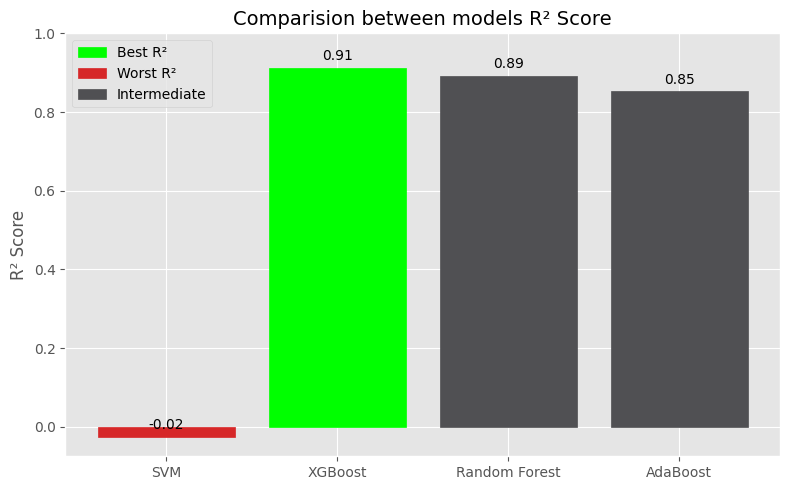

In [37]:
plt.style.use('ggplot')  

fig, ax = plt.subplots(figsize=(8,5))

colors = ['#d62728', "#00ff00", "#505053"]

bars = ax.bar(models, r2_scores, color=colors)

ax.set_title('Comparision between models R² Score', fontsize=14)
ax.set_ylabel('R² Score')

max_idx = r2_scores.index(max(r2_scores))
min_idx = r2_scores.index(min(r2_scores))

for i, bar in enumerate(bars):
    if i == max_idx:
        bar.set_color(colors[1])  
    elif i == min_idx:
        bar.set_color(colors[0]) 
    else:
        bar.set_color(colors[2])  
ax.set_ylim(min(r2_scores)-0.05, 1)

best = mpatches.Patch(color=colors[1], label='Best R²')
worst = mpatches.Patch(color=colors[0], label='Worst R²')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

ax.legend(handles=[best, worst, interm])

for bar in bars:
    altura = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, altura + 0.02,
            f'{altura:.2f}',
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

MAE

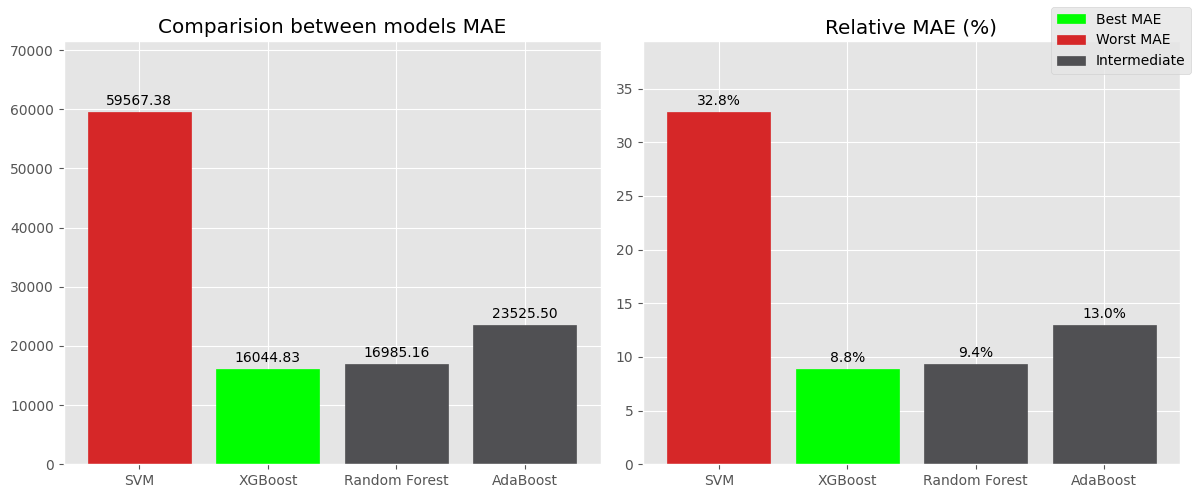

In [38]:
mean_prices = np.mean(train_target)
mae_rel = [(m / mean_prices) * 100 for m in mae]

max_idx = np.argmax(mae)  
min_idx = np.argmin(mae)  

fig, axs = plt.subplots(1, 2, figsize=(12,5))

bars1 = axs[0].bar(models, mae)

for i, bar in enumerate(bars1):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[0].set_title('Comparision between models MAE')
axs[0].set_ylim(0, max(mae) * 1.2)

for i, v in enumerate(mae):
    axs[0].text(i, v + max(mae)*0.02, f'{v:.2f}', ha='center')

bars2 = axs[1].bar(models, mae_rel)

for i, bar in enumerate(bars2):
    if i == min_idx:
        bar.set_color(colors[1])
    elif i == max_idx:
        bar.set_color(colors[0])
    else:
        bar.set_color(colors[2])

axs[1].set_title('Relative MAE (%)')
axs[1].set_ylim(0, max(mae_rel) * 1.2)

for i, v in enumerate(mae_rel):
    axs[1].text(i, v + max(mae_rel)*0.02, f'{v:.1f}%', ha='center')


best = mpatches.Patch(color=colors[1], label='Best MAE')
worst = mpatches.Patch(color=colors[0], label='Worst MAE')
interm = mpatches.Patch(color=colors[2], label='Intermediate')

fig.legend(handles=[best, worst, interm], loc='upper right', ncol=1)

plt.tight_layout()
plt.show()

## Models chosen: XGBoost & Random Forest

In [ ]:
from random import randint

for i in range(5):
    idx = randint(0, 1461)
    predx = xgb.predict([test.iloc[idx, 1:]])
    predr = rand_f.predict([test.iloc[idx, 1:]])    
    print(f'House {test.iloc[idx, 0]} price prediction: \nXGBoost: ${predx[0]:.2f}\nRandom Forest: ${predr[0]:.2f}')
    print(f'Random Forest price {(predr[0]/predx[0]):.2f}% {"lower." if predr[0]<predx[0] else "higher."}')

House 1900 price prediction: $149458.70
House 2049 price prediction: $131059.81
House 2005 price prediction: $229540.78
House 2775 price prediction: $114411.46
House 2466 price prediction: $102592.74


In [ ]:
houses = []
xgb_preds = []
rf_preds = []

for i in range(5):
    idx = randint(0, 1461)
    
    house_id = test.iloc[idx, 0]
    predx = xgb.predict([test.iloc[idx, 1:]])[0]
    predr = rand_f.predict([test.iloc[idx, 1:]])[0]
    
    houses.append(str(house_id))
    xgb_preds.append(predx)
    rf_preds.append(predr)

# posições no eixo x
x = range(len(houses))

# largura das barras
width = 0.35

plt.figure(figsize=(10,6))

# barras lado a lado
plt.bar([i - width/2 for i in x], xgb_preds, width=width, label='XGBoost')
plt.bar([i + width/2 for i in x], rf_preds, width=width, label='Random Forest')

plt.xticks(x, houses)
plt.xlabel("House ID")
plt.ylabel("Predicted Price")
plt.title("Comparação de Preços Previstos")

plt.legend()
plt.tight_layout()
plt.show()